# Multi-Document RAG System  

#### My Questions: 
(Questions I have to actively learn & master by using this new skillset in real-life) 
1. What is RAG? 
2. Why it matters? 
3. When to use? 
4. How to use? Key code patterns 
5. Real-World Applications? (what real-life problems it can solve)
6. Key trade-offs (differences) with its similar tools? 

#### Content Outline 
1. Introduction 
2. Step 1: Loading the Raw Knowledge
3. Step 2: Chunking 
4. Step 3: Embeddings
5. Step 4: The Vector Store
6. Step 5: The Brain 
7. Step 6: Putting It All Together 
8. Summary

RAG connects the powerful reasoning of an LLM with the unique information in your own documents. 

Today, I'll teach you how to build a Multi-Document RAG System using Python. By the end, you'll have an app that reads a folder of documents and answers your questions accurately. 

#### Multi-Document RAG System: Getting Started

We are going to build a Multi-Document RAG system from scratch using **Python, LangChain, and Ollama**. It sounds comples, but I promise you, it's just a series of logical steps. 

We'll use LangChain for orchestration, Chroma for storage, and Ollama to run the Llama 3 model locally. 

First, install these libraries. In your **terminal**, run: 


In [ ]:
pip install langchain langchain-community langchain-huggingface langchain-chroma langchain-ollama pypdf

You'll also need **Ollama** running locally with the Llama 3 model. After installing Ollama, **running ollama pull llama3.**

#### Step 1: Loading the Raw Knowledge 

First, gather your source materials. We need to **extract text from PDF files**. **PyPDFLoader** is a good choice because it handles the tricky formatting of PDFs well: 

In [ ]:
import os 
from langchain_community.document_loaders import PyPDFLoader

def load_documents(folder_path: str):
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"folder '{folder_path}' does not exist")

    documents = []
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".pdf"):  # case-insensitive
            file_path = os.path.join(folder_path, filename)
            print(f"📄 Loading: {filename}")
            try: 
                loader = PyPDFLoader(file_path) # pass PDF file, not folder
                documents.extend(loader.load())
            except Exception as e:
                print(f"❌ Error loading {filename}: {e}")
    return documents


In [ ]:
# Run the loader
folder_path = "data"
docs = load_documents(folder_path)
print("Total documents loaded:", len(docs))

In [ ]:
import os
print("Current working directory:", os.getcwd())
print("Contents:", os.listdir(os.getcwd()))

Data is rarely perfect. Make sure your loading logic skips non-PDFs and handles error, so your pipeline keeps running even is one file is bad. 

#### Step 2: Chunking 

Why? 
You can't give a 100-page document to an LLM all at once because it goes over the memory limit. So, we need to break it into smaller parts. 

How? 
We use **RecursiveCharacterTextSplitter**, which is a smart tool. It tries to split text by paragraphs first, then by sentences, so related text stays together: 

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

def split_text(documents):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200,
    )
    chunks = splitter.split_documents(documents)
    print(f"✂️ Created {len(chunks)} chunks")
    return chunks

Pay attention to **chunk_overlap=200**. This setting is important because it creates a sliding window, making sure you don't lose context if a sentence is split between chunks. 

#### Step 3: Embeddings

Computers understand numbers, not words. So, we need to turn our chunks into lists of numbers, called **vectors** or **embeddings**.

This means that if two chunks have similar meanings, like "Dog" and "Puppy", their numbers will be close to each other:

**sys.executable** targets the **exact Python** your notebook is running — no more mismatch.

In [ ]:
import sys
!{sys.executable} -m pip install --upgrade pip setuptools wheel
!{sys.executable} -m pip install --upgrade --force-reinstall sentence-transformers huggingface_hub

In [ ]:
# Debug

# Step 1: Uninstall the broken version
import sys
!{sys.executable} -m pip uninstall sentence-transformers -y

# Step 2: Install a stable compatible version
!{sys.executable} -m pip install sentence-transformers==2.7.0


In [ ]:
# Step 3: Restart kernel, then verify
import sentence_transformers
print(sentence_transformers.__version__)  # Should print 2.7.0

In [ ]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)
print("✅ HuggingFaceEmbeddings is working!")

We'll use all-MiniLM-L6-v2, a lightweight, open-source model that runs quickly on your CPU. 

#### Step 4: The Vector Store

Now we need somewhere to store these numbers for fast searching. A regular SQL database isn't good for this, so we'll use a **Vector Database**. We'll use **Chroma**:


In [ ]:
from langchain_chroma import Chroma

def create_vector_store(chunks):
    vector_store = Chroma.from_documents( 
        documents=chunks,
        embedding=embedding_function, 
        persist_directory="./chroma_db",
        collection_name="rag_docs"
    )
    return vector_store

This function **saves the database** in a folder called **./chroma_db**. That way, you don't have to rebuild the database every time you restart the app; it stays saved. 

#### Step 5: The Brain 

This is the most important part. This function **links the user, the database, and the LLM**:

In [ ]:
import os 
from langchain_ollama import ChatOllama
from langchain_core.prompts import ChatPromptTemplate 
from langchain_core.runnables import RunnablePassthrough 
from langchain_core.output_parsers import StrOutputParser

def format_docs(docs):
    return "\n\n".join(doc.page_content for doc in docs)

def query_rag_system(query_text, vector_store):
    llm = ChatOllama(model="llama3.2") # Make sure you have Ollama installed and running! 
   
    retriever = vector_store.as_retriever(search_kwargs={"k": 3})
    
    prompt = ChatPromptTemplate.from_template(
    """
    You are a helpful assistant. 
    Answer ONLY using the context below. 
    If the answer is not present, say "I don't know."
    
    Context: 
    {context}
    
    Question:
    {question}
    """
)
    
    chain = (
        {
            "context": retriever | format_docs,
            "question": RunnablePassthrough(),
        } 
        | prompt 
        | llm 
        | StrOutputParser()
    )
    
    return chain.invoke(query_text)

First, it looks at the user's question and finds the top 3 most relevant chunks **(k=3)**. Then, it puts those chunks into a strict prompt: "**Answer ONLY using the context below.**" This helps stop the AI from making things up. 

#### Step 6: Putting It All Together

Finally, the main loop checks if a database already exists. If it doesn't, it processes the PDFs. Then, it starts a chat loop so you can ask questions. 

In [ ]:
# Verify Folder Path 
import os

folder = "/Users/yanbingjiang/Desktop/guided-ai-software-projects/multi-document-rag-system"
print(os.path.exists(folder))       # Should print True
print(os.listdir(folder))           # Should show your PDF file

In [ ]:
def main():
    folder_path = "/Users/yanbingjiang/Desktop/guided-ai-software-projects/multi-document-rag-system/data" # CHANGE THIS to your folder path
    
    if not os.path.exists("./chroma_db"):
        print("📦 No vector DB found. Creating one...")
        docs = load_documents(folder_path)
        chunks = split_text(docs)
        vector_store = create_vector_store(chunks)
        print("Vector database created")
    else: 
        print("📦 Loading existing vector DB...")
        vector_store = Chroma(
            persist_directory="./chroma_db",
            embedding_function=embedding_function, 
            collection_name="rag_docs"
        )
    
    while True:
        query = input("\n❓ Ask a question (or type 'exit'): ")
        if query.lower() == "exit":
            break 
        
        print("🤔 Thinking...")
        answer = query_rag_system(query, vector_store) 
        print("\n🧠 Answer:\n", answer)
        
if __name__ == "__main__":
    main()


In [ ]:
# Quick one-shot test without the loop
query = "What are the top tech jobs in 2025?"
answer = query_rag_system(query, vector_store)
print("\n🧠 Answer:\n", answer)

Here's the answer I got for the Tech Job Market Reports: 

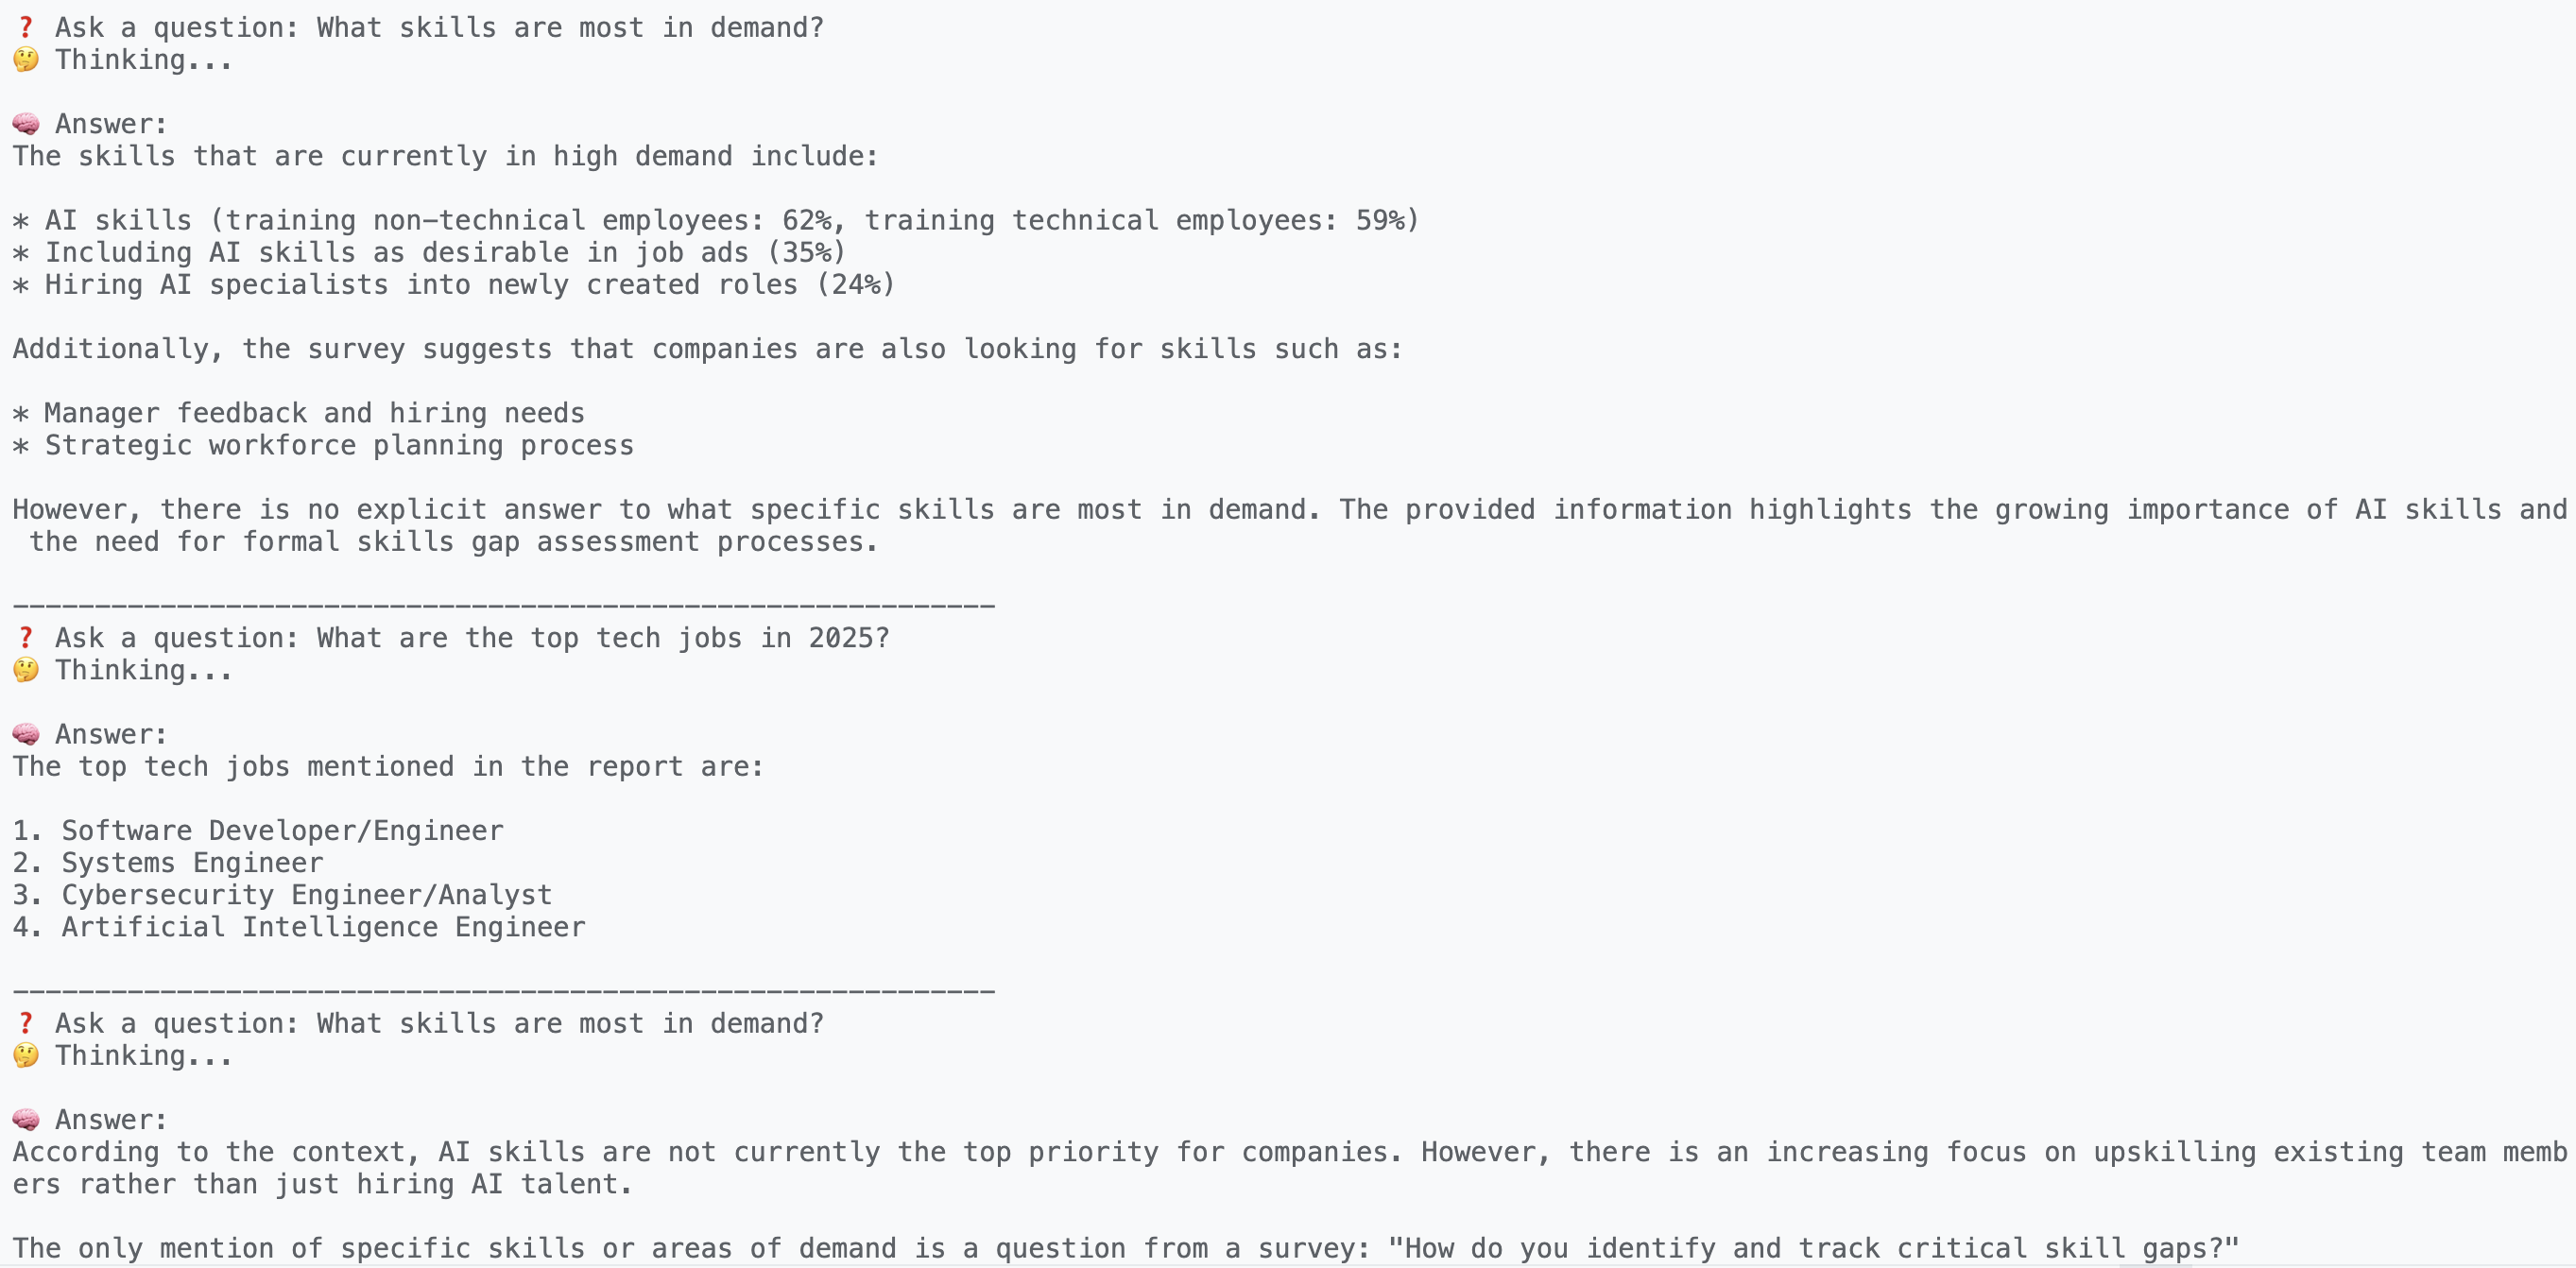

In [1]:
from IPython.display import Image
Image(filename="/Users/yanbingjiang/Desktop/guided-ai-software-projects/multi-document-rag-system/demo-image.png", height=300) # Optional: specify height or width

#### Closing Thoughts

Building systems like this shows me that AI isn't meant to replace our curiosity; it helps fuel it. When it's easier to find answers, we can ask better, deeper, and more creative questions. 

Don't be afraid to experiment with this code. Try changing the chunk size, swap llama3 for Mistral, or use a differnt embedding model. That's the best way to learn. 

#### Lessons / Reminder Notes: 
1. folder_path should be a FOLDER containing your documents, not your current file path.
2. Pay attention to **chunk_overlap=200**. This setting is important because it creates a **sliding window**, making sure you don't lose context if a sentence is split between chunks. 